# <font color="steelblue">250. Inferencia estadística sobre medias</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 10/05/2025

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

## <font color='steelblue'>Introducción</font>

**Descripción:** La inferencia sobre medias es un proceso estadístico que nos permite hacer conclusiones sobre la media de una población utilizando información de una muestra representativa. A través de técnicas de muestreo y análisis estadístico, podemos estimar y tomar decisiones sobre la media poblacional, teniendo en cuenta la incertidumbre asociada a la estimación.

Los intervalos de confianza para una media poblacional son herramientas estadísticas que nos permiten estimar un rango plausible de valores donde se espera que se encuentre la verdadera media de la población con un determinado nivel de confianza.

El contraste de hipótesis para una media poblacional es un procedimiento estadístico que nos permite evaluar si hay evidencia suficiente para rechazar o no una afirmación sobre la media de una población. A través de la especificación de una hipótesis nula y una hipótesis alternativa, se utiliza una prueba estadística para calcular la significancia de los resultados y tomar decisiones basadas en la evidencia obtenida.

La inferencia sobre una varianza poblacional implica la utilización de técnicas estadísticas para hacer inferencias sobre la variabilidad de una población. A través del análisis de una muestra representativa, se pueden estimar y realizar pruebas de hipótesis relacionadas con la varianza poblacional. Esto nos permite tomar decisiones y obtener conclusiones sobre la dispersión de los datos en la población en estudio.

La comparación de medias es un aspecto fundamental en la investigación estadística, en este cuaderno, nos centraremos en analizar si existen diferencias significativas entre los promedios de dos grupos o poblaciones.

El contraste de igualdad de varianzas es un paso crucial antes de realizar la comparación de medias, ya que asume que las varianzas de los grupos o poblaciones a comparar son iguales. Exploraremos los métodos estadísticos comunes para contrastar la igualdad de varianzas y discutiremos su importancia en la inferencia de medias.

Una vez que se ha verificado la igualdad de varianzas, podemos proceder a realizar el contraste de igualdad de dos medias. Este contraste nos permite determinar si existen diferencias significativas entre los promedios de dos grupos o poblaciones, asumiendo que las varianzas son iguales.

Cuando las varianzas de los grupos o poblaciones a comparar difieren significativamente, debemos utilizar métodos estadísticos que tengan en cuenta esta heterogeneidad. El contraste de igualdad de medias con varianzas diferentes se basa en pruebas estadísticas robustas que permiten realizar inferencias precisas incluso en presencia de varianzas desiguales.

Si las muestras que tenemos están relacionadas, es decir, son los mismos sujetos, pero en diferentes momentos en el tiempo, es un caso concreto muy común y que veremos qué prueba estadística hay que aplicar para poder sacar conclusiones sobre el contraste de estas dos muestras.


## <font color='steelblue'> Objetivos de aprendizaje

* Conocer los procedimeintos de inferencia estadística para el estudio de una media poblacional y aplicarlos a situaciones reales.

* Conocer los procedimeintos de inferencia estadística para el estudio de dos medias poblacionales y aplicarlos a situaciones reales.



## <font color='steelblue'> Contenidos </font>

1. Introducción
1. Inferencia estadística sobre una media poblacional
1. Inferencia estadística sobre una varianza poblacional
1. Tests no paramétrico para la inferencia estadística sobre una media poblacional
1. Función para resolver el problema de inferencia paramétrico de una media.
1. Introducción a la comparación de medias


## <font color='steelblue'> 1. Introducción

En este cuaderno nos centraremos en el análisis en profundidad de una media, o de la comparación de dos medias.

Antes que nada cargamos todos los módulos necesarios.

In [ ]:
# Cargamos módulos de análisis numérico
import numpy as np
import pandas as pd         # importamos pandas como pd
import math                 # importamos módulo para cáculos matemáticos

# Cargamos módulos de análisis gráficos
from plotnine import *      # importamos módulo para gráficos con ggplot
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
sns.set_theme(style="whitegrid")
%config InlineBackend.figure_format = 'retina'

from scipy import stats

Para ejemplificar el proceso de inferencia vamos a utilizar diferentes bancos de datos que cargamos a continuación. Su descripción está accesible en el correspondiente cuaderno de bancos de datos. Cargamos los datos:

In [ ]:
# Carga del banco de datos 'diabetes'
url = 'https://raw.githubusercontent.com/jmsocuellamos/DataPython/main/diabetes.csv'
diabetes = pd.read_csv(url)
# Recodificación
diabetes.Outcome.replace({0: "No Diabetes", 1: "Diabetes"}, inplace=True)

# LECTURA
url = 'https://raw.githubusercontent.com/jmsocuellamos/DataSeg/master/FBI.csv'
fbi = pd.read_csv(url, sep =";") # en este caso el separador de campos es el ; en lugar de ,
fbi

# Carga del banco de datos 'iris'
url = 'https://raw.githubusercontent.com/jmsocuellamos/DataPython/main/IRIS.csv'
iris = pd.read_csv(url)

<ipython-input-2-7c9748b44344>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




## <font color='steelblue'> 2. Inferencia paramétrica sobre una media poblacional

En el bloque anterior trabajamos con variables cualitativas, con diferentes niveles cada una de ellas, y ahora es el turno de las variables cuantitativas. A partir de una muestra que se extraerá de la población, podremos obtener la media y la desviación típica (o varianza) de la variable cuantitativa que queremos estudiar para sacar conclusiones para la población.

Lo habitual es asumir normalidad en los datos, hecho que nos permite utilizar ciertos cálculos probabilísticos basados en esta distribución para resolver la inferencia sobre las medias y extrapolar a toda la población a través de muestras. Cuando la normalidad no se cumple, es decir, se rechaza con un test de normalidad, hemos de echar mano de otros procedimientos inferenciales que no están basados en medias, sino en medianas o rangos.

Por ese motivo el primer paso en el análisis de medias es verificar la hipótesis de Normalidad.

### <font color='steelblue'> Consideraciones previas: Normalidad de variables

Para ver si la variable sigue esta distribución o no, debemos de realizar un contraste de hipótesis de normalidad, que se plantea cómo:

$$
\left\lbrace\begin{array}{l} H_0: los~datos~siguen~una~distribución~Normal \\ H_1: H_0~no~es~cierta,~los~datos~no~siguen~una~distribución~Normal \end{array}\right.
$$

Si queremos contrastar estas hipótesis, debemos utilizar el [**test de Kolmogorov-Smirnoff**](https://es.wikipedia.org/wiki/Prueba_de_Kolmog%C3%B3rov-Smirnov) y nos ayudaremos de la función `ktest` del módulo `scipy.stats`.

Para ejemplificar el uso de la función vamos a verificar la normalidad de las variables `BMI` y `Age` del banco de datos `diabetes`.

In [ ]:
# Análisis de normalidad para BMI
# Test de normalidad donde especificamos los datos y la distribución de interés,
# con sus parámetros media y desviación típica de la muestra
df = diabetes['BMI']
print('BMI KS pvalue: ', stats.kstest(df, stats.norm.cdf, args = (df.mean(), df.std())).pvalue)

BMI KS pvalue:  0.05169115513208089


Dado que el p-valor resulta no significativo (superior a 0.05) tenemos evidencias para no rechzazar la hipótesis de normalidad de la variable `BMI`.

In [ ]:
# Análisis de normalidad para Age
# Test de normalidad donde especificamos los datos y la distribución de interés,
# con sus parámetros media y desviación típica de la muestra
df = diabetes['Age']
print('Age KS pvalue: ', stats.kstest(df, stats.norm.cdf, args = (df.mean(), df.std())).pvalue)

Age KS pvalue:  7.023775237757875e-17


El p-valor resulta significativo (inferior a 0.05) indicando que la variable `Age` no verifica la hipótesis de Normalidad. En esta situación no podemos utilizar los procedimientos que presentamos a continuación, que se basan en asumir que la varaible deinterés se distribuye medante una variable aleatoria:

$$X \sim N(\mu, \sigma).$$

Además en cuadernos anteriores ya vimos que la distribución en el muestreo de la media muestral viene dada por:


$$\bar{X} \sim N\left(\mu, \frac{\sigma}{\sqrt{n}}\right), \text{ cuando } \sigma \text{ es conocida.}$$

$$\bar{X} \sim T_{n-1}\left(\mu, \frac{s}{\sqrt{n}}\right), \text{ cuando } \sigma \text{ es desconocida.}$$


### <font color='steelblue'> Intervalo de confianza

Fijado el nivel de confianza $\alpha$ y utilizando la dstribución en el muestreo de $\bar{X}$, el intervalo de confianza al nivel $100(1-\alpha)\%$ viene dado por la expresión:

$$[\hat{\theta} - q_{1-\alpha/2} \cdot se(\hat{\theta}), \hat{\theta} + q_{1-\alpha/2}\cdot se(\hat{\theta})]$$

donde:

* $q_{1-\alpha/2}$ es el cuantil $1-\alpha/2$ de una distribución $N(0,1)$ o una $T_{n-1}(0,1)$, en función de si la varianza es conocida o desconocida.
* $se(\bar{X})$ es el error estándar de estimación que viene dado por:

$$\frac{\sigma}{\sqrt{n}} \text{ o } \frac{s}{\sqrt{n}}$$

si la varianza es conocida o desconocida respectivamente.

En la práctica real la varianza suele ser también desconocida y optamos simpre por esta solución para resolver el probelam de inferencia sobre la media poblacional.

### <font color='steelblue'> Contraste de hipótesis

Para el establecimiento de un contraste de hipótesis sobre una proporción poblacional consideramos:

* El valor $\mu_0$ con el que deseamos comparar la proporción poblacional $\mu$.
* La significatividad con la que vamos a conluir nuestro procedimiento de contraste, $\alpha$.
* El estadístico que vamos a utilizar para resolver el contraste es

$$EC = \frac{\mu - \mu_0}{se(\bar{X})}$$

El estadístico de contraste refleja lo cerca o lejos que se encuentra el valor $\mu_0$ del valor poblacional, en términos del error muestral que estamos comentiendo. Además el valor del estadístico de contraste observado (necesario para obtener el p-valor) viene dado por:

$$EC_{obs} = \frac{\bar{x} - \mu_0}{se(\bar{X})}$$

que refleja la diferencia entre el valor muestral y el valor que deseamos contrastar.

A continuación se  muestran Los contrastes que podemos plantear.






#### <font color='steelblue'> Contraste bilateral

Comenzamos con el contraste habitual donde queremos ver si la proporción poblacional toma cierto valor. Aunque es muy habitual también es el que tiene menos sentido práctico ya que estamos siendo muy restrictivos en el posible valor que puede tomar la proporción poblacional. El contraste viene dado por:

$$\left\lbrace\begin{array}{l}
H_0: \mu = \mu_0\\
H_a: \mu \neq \mu_0
\end{array}\right.$$

#### <font color='steelblue'> Contraste unilateral a la izquierda

El contraste unilateral a la izquierda viene dado por:

$$\left\lbrace\begin{array}{l}
H_0: \mu \leq \mu_0\\
H_a: \mu > \mu_0
\end{array}\right.$$

#### <font color='steelblue'> Contraste unilateral a la derecha

El contraste unilateral a la izquierda viene dado por:

$$\left\lbrace\begin{array}{l}
H_0: \mu \geq \mu_0\\
H_a: \mu < \mu_0
\end{array}\right.$$

### <font color='steelblue'> Función para resolver el problema de inferencia paramétrico de una media

Para facilitar la realización del proceso inferencial sobre una media o una varianza se define la función siguiente.

In [ ]:
def inferencia_una_media_varianza(df, var, inferencia, alpha, val_hip, hipotesis):
  """
  Inferencia sobre una media o una varianza poblacional: intervalo de confianza bilateral y
  el contraste de hipótesis que queramos

  Parámetros:
    - df: muestra de la población
    - var: variable (cuantativa) de interés
    - inferencia: indicaremos sobre qué queremos hacer inferencia ('media' o 'varianza')
    - alpha: nivel de significación
    - val_hip: valor que establecemos en el contrate de hipótesis, p0
    - hipotesis: tipo de hipótesis ('bilateral', 'uni izq', 'uni der')

  Devuelve:
    Un data frame con el intervalo de confianza, el estadístico de contraste, el p-valor y el
    resultado del contraste entre otras cosas en las columnas
  """
  # Preparación de datos
  variable_muestral = df[var]
  # Variable sin valores perdidos
  variable_muestral = variable_muestral[variable_muestral.notnull()]
  # Tamaño muestra
  n = len(variable_muestral)

  ## Estimadores muestrales

  # Media muestral
  media_muestral = variable_muestral.mean()
  # Desviación típica muestral insesngada
  desv_tip_muestral = variable_muestral.std()
  # Varianza muestral insesngada
  var_muestral = variable_muestral.var()

  ## Tipo de inferencia
  if inferencia == "media":
    est = media_muestral
    # Error muestral
    error_muestral = desv_tip_muestral/(n**0.5)
    ## Proceso inferencial

    # Intervalo de confianza bilateral
    valor_critico_bilateral = stats.norm.isf(alpha/2)
    lim_inf = media_muestral - valor_critico_bilateral*error_muestral
    lim_sup = media_muestral + valor_critico_bilateral*error_muestral

    # Estadístico de contraste observado, valor crítico, planteamiento hipótesis nula utilizada y p-valor, dependiendo del contraste que queramos
    # si queremos un contraste de hipótesis bilateral, a dos colas
    if hipotesis == 'bilateral':
      est_contraste = abs(media_muestral - val_hip)/error_muestral
      valor_critico = valor_critico_bilateral
      valor_critico = round(valor_critico, 4)
      texto_hip = f'H0: 𝜇 = {val_hip}'
      p_valor = stats.norm.sf(est_contraste)*2
    # si queremos un contraste de hipótesis unilateral a la izquierda
    elif hipotesis == 'uni izq':
      est_contraste = (media_muestral - val_hip)/error_muestral
      valor_critico = -stats.norm.isf(alpha)
      valor_critico = round(valor_critico, 4)
      texto_hip = f'H0: 𝜇 ≥ {val_hip}'
      p_valor = 1-stats.norm.sf(est_contraste)
    # si queremos un contraste de hipótesis unilateral a la derecha
    elif hipotesis == 'uni der':
      est_contraste = (media_muestral - val_hip)/error_muestral
      valor_critico = stats.norm.isf(alpha)
      valor_critico = round(valor_critico, 4)
      texto_hip = f'H0: 𝜇 ≤ {val_hip}'
      p_valor = stats.norm.sf(est_contraste)
    # si no indicamos bien el tipo de contraste, nos mostrará un error
    else:
      est_contraste = 0
      valor_critico = 0
      texto_hip = "Ponga un tipo de contraste válido"
      p_valor = 0

  elif inferencia == "varianza":
    est = var_muestral
    ## Proceso inferencial

    # Intervalo de confianza bilateral
    # Valor crítico inferior, a 2 colas
    vc_inf = stats.chi2.isf(alpha/2, df=n-1)
    # Valor crítico superior, a 2 colas
    vc_sup = stats.chi2.isf(1-alpha/2, df=n-1)

    # Límite inferior del intervalo
    lim_inf = (n-1)*var_muestral/vc_inf
    # Límite superior del intervalo
    lim_sup = (n-1)*var_muestral/vc_sup

    # Coeficiente entre la varianza muestral y la que vamos a contrastar
    coef = var_muestral/val_hip

    # Estadístico de contraste
    est_contraste = (n-1)*var_muestral/val_hip

    # Planteamiento hipótesis nula utilizada y p-valor, dependiendo del contraste que queramos
    # si queremos un contraste de hipótesis bilateral, a dos colas
    if hipotesis == 'bilateral':
      # lista con los valores críticos
      valor_critico = (round(stats.chi2.isf(1-alpha/2, df=n-1), 4),
                       round(stats.chi2.isf(alpha/2, df=n-1), 4))
      texto_hip = f'H0: 𝜎2 = {val_hip}'
      if coef < 1:
        p_valor = (1-stats.chi2.sf(est_contraste, df=n-1))*2
      else:
        p_valor = stats.chi2.sf(est_contraste, df=n-1)*2
    # si queremos un contraste de hipótesis unilateral a la izquierda
    elif hipotesis == 'uni izq':
      valor_critico = stats.chi2.isf(1-alpha, df=n-1)
      valor_critico = round(valor_critico, 4)
      texto_hip = f'H0: 𝜎2 ≥ {val_hip}'
      if coef < 1:
        p_valor = stats.chi2.sf(est_contraste, df=n-1)
      else:
        p_valor = 1-stats.chi2.sf(est_contraste, df=n-1)
    # si queremos un contraste de hipótesis unilateral a la derecha
    elif hipotesis == 'uni der':
      valor_critico = stats.chi2.isf(alpha, df=n-1)
      valor_critico = round(valor_critico, 4)
      texto_hip = f'H0: 𝜎2 ≤ {val_hip}'
      if coef < 1:
        p_valor = 1-stats.chi2.sf(est_contraste, df=n-1)
      else:
        p_valor = stats.chi2.sf(est_contraste, df=n-1)
    # si no indicamos bien el tipo de contraste, nos mostrará un error
    else:
      est_contraste = 0
      valor_critico = 0
      texto_hip = "Ponga un tipo de contraste válido"
      p_valor = 0
  else:
      est_contraste = 0
      valor_critico = 0
      texto_hip = "Ponga un parámetro válido para inferenciar"
      p_valor = 0

  # Conclusión del contraste
  if p_valor < alpha:
    conc = 'Rechazamos H0'
  else:
    conc = 'No rechazamos H0'

  # Especificación de los resultados que se devolverán en un diccionario
  data = {f'{inferencia.title()} muestral': [format(est, '6.3f')],
          'Límite inferior del IC': [format(lim_inf, '6.3f')],
          'Límite superior del IC': [format(lim_sup, '6.3f')],
          'Hipótesis nula': [texto_hip],
          'Estadístico de contraste': [format(est_contraste, '6.3f')],
          'Valor crítico': [valor_critico],
          'p-valor': [format(p_valor, '6.3f')],
          'nivel de significación': [alpha],
          'Conclusión': [conc]}
  # Transformamos el diccionario en un DataFrame, con la fila que se llame "Inferencia de una media" o "Inferencia de una varianza"
  respuesta = pd.DataFrame(data,index = [f'Inferencia de una {inferencia}'])
  return respuesta

## <font color='steelblue'> 3. Inferencia paramétrica sobre una varianza poblacional

Una vez hemos visto cómo realizar inferencia para la media poblacional, vamos a explicarla para la varianza poblacional. Esta medida de variabilidad poblacional representa la dispersión de los datos en una población. Es la media de las desviaciones al cuadrado de cada valor respecto a la media poblacional. Una varianza poblacional alta indica que los datos están más dispersos, mientras que una varianza baja sugiere que los datos están más concentrados en torno a la media. Como bien sabemos, es difícil saber los datos de una población entera, por lo que se estiman a partir de una muestra que se extrae de esta población. Para inferir sobre la varianza poblacional, se utiliza la varianza muestral insesgada como estimador. La varianza muestral se calcula a partir de una muestra de datos y proporciona una estimación de la variabilidad en la población. Se obtiene sumando las diferencias al cuadrado entre cada valor y la media muestral, y dividiendo por el tamaño de la muestra menos uno. Como ya sabemos, la extensión a utilizar en este caso es `.var()` y para que sea insesgada, es decir, se divida la suma de estas diferencias entre $n-1$, no hay que añadir nada, ya que por defecto tenemos que `ddof=1`.

La distribución de la varianza muestral sigue una distribución *chi-cuadrado* con $n-1$ grados de libertad, donde $n$ es el tamaño de la muestra. Esto significa que la forma de esta distribución depende del tamaño de la muestra, y se va desplazando hacia la derecha a medida que esta aumenta, como hemos visto en cuadernos anteriores. En este caso, utilizaremos la función `chi2` del módulo `scipy.stats`, dónde tendremos que indicar los grados de libertad en el argumento `df`.

Una vez hemos introducido estos conceptos, ya podemos pasar a realizar inferencia sobre esta medida. Empecemos por los intervalos de confianza. La fórmula que utilizaremos cambia totalmente con respecto a la proporción y a la media poblacional, ya que como la distribución $\chi^2$ no es simétrica respecto a $0$, habrá un valor crítico para el límite superior y otro para el inferior. Para un intervalo de confianza tendremos:

$$
IC = (\frac{(n-1) \cdot s^2}{\chi^2_{n-1,~\alpha/2}}, \frac{(n-1) \cdot s^2}{\chi^2_{n-1,~1-\alpha/2}})
$$

En este caso nuestro parámetro será la varianza muestral insesgada $s^2~= \frac{\sum_{i=1}^n (X_i - \bar{X})^2}{n-1}$.

Para los procedimientos de contraste utilizamos los mismos contrastes bilateral y unilateral que el caso de las medias pero sobre la varianza poblacional:

$$\left\lbrace\begin{array}{l}
H_0: \sigma^2 = \sigma^2_0\\
H_a: \sigma^ \neq \sigma^2_0
\end{array}\right.$$

$$\left\lbrace\begin{array}{l}
H_0: \sigma^2 \leq \sigma^2_0\\
H_a: \sigma^ > \sigma^2_0
\end{array}\right.$$

$$\left\lbrace\begin{array}{l}
H_0: \sigma^2 \geq \sigma^2_0\\
H_a: \sigma^ < \sigma^2_0
\end{array}\right.$$

## <font color='steelblue'> 4. Inferencia no paramétrica  sobre una media poblacional

Cuando la normalidad no se cumple, es decir, se rechaza con un test de normalidad, hemos de echar mano de otros procedimientos inferenciales que no están basados en medias, sino en medianas o rangos.

El test que utilizaremos es el conocido como [**test de Wilcoxon**](https://es.wikipedia.org/wiki/Prueba_de_los_rangos_con_signo_de_Wilcoxon) para una sola muestra, que susituye a los test paramétricos de la Normal y la t de Student. Lo que hace es ver si la distribución existente entre la muestra y el valor con el que contrastemos es simétrica alrededor de $0$. Los contrastes de hipótesis son los mismos que vimos en cuadernos anteriores:

* **Contraste de hipótesis bilateral:** queremos comprobar si la media poblacional es significativamente igual o no a una media determinada.

$$
\left\lbrace\begin{array}{c} H_0: \mu = 0 \\ H_1: \mu \neq 0 \end{array}\right.
$$

* **Contraste de hipótesis unilateral a la izquierda:** se contrastará si la media poblacional es significativamente igual o mayor, o no, que una media determinada.

$$
\left\lbrace\begin{array}{c} H_0: \mu \geq 0 \\ H_1: \mu \lt 0 \end{array}\right.
$$

* **Contrastes de hipótesis unilaterales a la derecha:** vamos a contrastar si la media poblacional es significativamente igual o menor, o no, que una media determinada.

$$
\left\lbrace\begin{array}{c} H_0: \mu \leq 0 \\ H_1: \mu \gt 0 \end{array}\right.
$$

La función que utilizaremos para utilizar el test de Wilcoxon, es `wilcoxon` del módulo `stats.scipy`. Los argumentos que utilizaremos son:

* `x`: lista que contiene los valores menos el valor que se utiliza para el contraste. Lo que hará es restarle a cada dato de la variable de la muestra el valor determinado $\mu_0$. Si queremos contrastar con $2$, escribiremos: `valores-2`.

* `alternativa`: indicamos la hipótesis alternativa a utilizar. Si estamos en un contraste bilateral, pondremos `"two-sided"`; si estamos en uno unilateral a la izquierda, `"less"`; y si el contraste es unilateral a la derecha, igualaremos el argumento a `"greater"`.

Si deseamos contrastar un valor específico ($\mu_0$) debemos corregir la muestra original de datos por ese valor ($x - \mu_0$ para poder realizar el contraste deseado.

## <font color='steelblue'> 5. Ejemplos inferencia sobre una media-varianza poblacional

A continuación mostramos diferentes ejemplos de inferencia sobre una media o una varianza poblacional utilizando la función anterior.

**Ejemplo 1.** Comenzaremos por investigar la posibilidad de que la media el índice de masa corporal sea superior a 33, y si la varianza es inferior a 62. En base a la información proporcionada los contrastes de hipótesis para resolver los problemas de inferencia planteados vienen dados por:

$$\left\lbrace\begin{array}{l}
H_0: \mu \leq 33\\
H_a: \mu > 33
\end{array}\right.$$

$$\left\lbrace\begin{array}{l}
H_0: \sigma^2 \geq 62\\
H_a: \sigma^2 < 62
\end{array}\right.$$

Para resolverlo fijamos el valor de $\alpha = 0.05$ y ejecutamos la función anterior con los argumentos que corresponden:

In [ ]:
inferencia_una_media_varianza(diabetes, 'BMI', 'media', 0.05, 33, "uni der")

,Media muestral,Límite inferior del IC,Límite superior del IC,Hipótesis nula,Estadístico de contraste,Valor crítico,p-valor,nivel de significación,Conclusión
Inferencia de una media,31.993,31.435,32.550,H0: 𝜇 ≤ 33,-3.541,1.6449,1.000,0.05,No rechazamos H0


Con una confianza del 95% la media del índice de masa corporal se sitúa en el intervalo $[31.4,32.6]$, mientras que el contraste resulta no significativo (p-valor mayor que 0.05) lo que nos permite establecer que hay evidencias estadísticas para concluir que la media del índice de masa corporal es inferior a 33.

In [ ]:
inferencia_una_media_varianza(diabetes, 'BMI', 'varianza', 0.05, 62, "uni izq")

,Varianza muestral,Límite inferior del IC,Límite superior del IC,Hipótesis nula,Estadístico de contraste,Valor crítico,p-valor,nivel de significación,Conclusión
Inferencia de una varianza,62.160,56.379,68.882,H0: 𝜎2 ≥ 62,768.979,703.7341,0.527,0.05,No rechazamos H0


Con una confianza del 95% la varianza del índice de masa corporal se sitúa en el intervalo $[56.4,68.9]$, mientras que el contraste resulta no significativo (p-valor mayor que 0.05) lo que nos permite establecer que hay evidencias estadísticas para concluir que la varianza del índice de masa corporal es mayor o igual a 62.

**Ejemplo 2.** Queremos investigar ahora si se puede considerar que la media de la glucosa para los sujetos no diabéticos puede considerarse menor a 100. En este caso deberemos seleccionar los sujetos y verificar en primer lugar la normalidad antes de proceder con el procedimiento de contraste adecuado que en este caso viene dado por:

$$\left\lbrace\begin{array}{l}
H_0: \mu \geq 100\\
H_a: \mu < 100
\end{array}\right.$$

Seleccionamos los datos adecuados

In [ ]:
df = diabetes.loc[diabetes['Outcome'] == "No Diabetes","Glucose"]

Verificamos la hipótesis de normalidad

In [ ]:
print('BMI KS pvalue: ', stats.kstest(df, stats.norm.cdf, args = (df.mean(), df.std())).pvalue)

BMI KS pvalue:  0.045274718509862755


Dado que el p-valor resulta significativo (inferior a 0.05) podemos concluir que no se verifica la hipótesis de normalidad. En este caso debemos proceder con un test no parámetrico para resolver el contraste planteado. Debemos corregir la muestra original con el valor que deseamos utilizar en el contraste.

In [ ]:
# p-valor
stats.wilcoxon(x=df-100, alternative="greater", method = 'approx').pvalue

6.603503043819125e-16

Como el test resulta significativo (rechazamos la hipótesis nula) podemos concluir que la media de glucosa para los individuos sanos no es inferior a 100.

**Ejemplo 3.** Queremos investigar ahora si se puede considerar que la media de la presión sangüínea en los sujetos diabéticos puede ser superior a 75. De nuevo, en primer lugar debemos verificar la hipótesis de Normalidad. El contraste que deseamos resolver:

$$\left\lbrace\begin{array}{l}
H_0: \mu \leq 75\\
H_a: \mu > 75
\end{array}\right.$$

Seleccionamos los datos y verificamos la hipótesis de normalidad.

In [ ]:
# Datos
df = diabetes.loc[diabetes['Outcome'] == "Diabetes","BloodPressure"]
# Test de normalidad
print('BMI KS pvalue: ', stats.kstest(df, stats.norm.cdf, args = (df.mean(), df.std())).pvalue)

BMI KS pvalue:  2.036141929382449e-09


Rechazamos la hipótesis de normalidad y procedemos con el contraste no paramétrico.

In [ ]:
# p-valor
stats.wilcoxon(x=df-75, alternative="less", method = 'approx').pvalue

0.08011091257088826

No rechazamos la hipótesis nula.

**Ejemplo 4.** Queremos investigar ahora si se puede considerar si la media de la anchura de pétalo para las palnatas de la especie iris-virginica es igual 2. De nuevo, en primer lugar debemos verificar la hipótesis de Normalidad. El contraste que deseamos resolver:

$$\left\lbrace\begin{array}{l}
H_0: \mu = 2\\
H_a: \mu \neq 2
\end{array}\right.$$

Seleccionamos datos y verificamos la normalidad

In [ ]:
# Datos
df = iris.loc[iris["species"]=="Iris-virginica","petal_width"]
# Normalidad
print('KS pvalue: ', stats.kstest(df, stats.norm.cdf, args = (df.mean(), df.std())).pvalue)

KS pvalue:  0.4257938210753581


Se verifica la hipótesis de normalidad (p-valor > 0.05) y podemos proceder con el test parámetrico correspondiente.

In [ ]:
inferencia_una_media_varianza(iris[iris["species"]=="Iris-virginica"], 'petal_width', 'media', 0.05, 2, "bilateral")

,Media muestral,Límite inferior del IC,Límite superior del IC,Hipótesis nula,Estadístico de contraste,Valor crítico,p-valor,nivel de significación,Conclusión
Inferencia de una media,2.026,1.950,2.102,H0: 𝜇 = 2,0.669,1.96,0.503,0.05,No rechazamos H0


El intervalo de confianza al 95% de la anchura de pétalo para las flores de la especie Iris-virginica se sitúa en el intervalo [1.95, 2.10], mientras que el contraste de hipótesis resulta no significativo obteniendo evidencias de que la media de dicha variable es igual a 2.

## <font color='steelblue'> 6. Comparación de dos medias

En los puntos anteriores hablamos sobre la inferencia con una media o una varianza muestral, para poder acotar o contrastar los respectivos parámetros poblacionales. Avanzando un poco, vamos a hablar ahora del contraste de igualdad entre 2 medias poblacionales. En este cuaderno, no hablaremos de intervalos de confianza, tan solo vamos a realizar contrastes de hipótesis. Esta técnica es ampliamente utilizada en diversas disciplinas, desde la medicina hasta las ciencias sociales, para evaluar el impacto de diferentes tratamientos, intervenciones o variables en el resultado de interés. En muchas ocasiones, este tipo de contraste se realiza en un mismo grupo de sujetos, tomando medidas sobre una variable cuantitativa antes y después de un tratamiento, o bien se puede comparar la media entre un grupo que toma un fármaco y otro que toma un placebo. De esta forma, podremos ver si hay diferencias o no entre ambos grupos, pudiendo ver también la media de que grupo es mayor. La cuestión de interés es comparar ambos grupos para descubrir si efectivamente identifican a poblaciones distintas. Resolver esta cuestión es equivalente a concluir si el factor de clasificación está relacionado con la variable de interés, diferenciando poblaciones.

Antes de pasar a contrastar las medias de ambos grupos y ver si existen diferencias, tenemos que comprobar si las varianzas de estos grupos son iguales o diferentes. Por lo que antes de realizar el contraste de hipótesis para las dos medias, tendremos que contrastar de manera bilateral las varianzas: $H_0: \sigma_X^2 = \sigma_Y^2$.

Este contraste previo se tiene que hacer porque tendremos que seleccionar diferentes pruebas estadísticas dependiendo de si las varianzas son iguales o si son diferentes. En cada uno de los casos, se deberá aplicar unos cálculos diferentes.

También es necesario verificar la hipótesis de normalidad de las mediciones de ambos grupos con el test adecuado. En caso de no cumlirse alguna de las hipótesis deberemos abordar un test no paramétrico.


### <font color='steelblue'> Consideraciones previas

Antes de presentar formalmente los procedimientos de inferencia para la comparación de las medias de dos poblaciones independientes, es necesario presentar los procedimientos para la verificación de hipótesis de normalidad y de igualdad de varianzas. El cumplimiento o cincumplimneto de estas hipótesis nos indicará el procedimeinto de inferencia adecuado en cada situación experimental como veremos más adelante.

#### <font color='steelblue'> Contraste de igualdad de varianzas

Vamos a empezar a trabajar con muestras independientes, es decir, no tienen nada que ver una de la otra, pueden venir de la misma población, pero serán sujetos diferentes. Una vez hemos visto que antes de pasar al contraste entro las medias de dos grupos o poblaciones hay que realizar el contraste de igualdad de sus varianzas, vamos a pasar a explicarlo. En la hipótesis nula pondremos la igualdad, mientras que en la alternativa irá la desigualdad, quedando de la siguiente forma:

$$
\left\lbrace\begin{array}{c} H_0:\sigma_X^2 = \sigma_Y^2 \\ H_1: \sigma_X^2 \neq \sigma_Y^2 \end{array}\right.
$$

El subíndice $X$ hace referencia al primer grupo  y el segundo se indica con el subíndice $Y$. Este contraste permite evaluar si existe evidencia estadística para afirmar que las varianzas son similares o si, por el contrario, difieren de manera significativa. La hipótesis nula hará referencia al primer par de gráficos que hemos visto en el apartado anterior, mientras que los últimos 2 gráficos corresponden a la hipótesis alternativa.

Cuando comparábamos dos proporciones, podíamos pasar uno de los dos parámetros al otro lado restando, pero en este caso para pasar de un lado al otro de la igualdad (o desigualdad) tendrán que ir dividiendo. Por lo tanto, la igualdad nos quedará también cómo:

$$
\left\lbrace\begin{array}{c} H_0: \sigma_X^2 = \sigma_Y^2 \\ H_1: \sigma_X^2 \neq \sigma_Y^2 \end{array}\right. ó \left\lbrace\begin{array}{c} H_0: \frac{\sigma_Y^2}{\sigma_X^2} = 1 \\ H_1: \frac{\sigma_Y^2}{\sigma_X^2} \neq 1 \end{array}\right.
$$

Para el coeficiente que se compara con $1$, da igual si va arriba la varianza del primer grupo o del segundo. Este coeficiente le llamaremos **coeficiente de varianzas** y sigue una distribución [**F de Snedecor**](https://es.wikipedia.org/wiki/Distribuci%C3%B3n_F).


Para resolver el constraste podemos utilizar diferentes tests aunuqe el más habitual es el test de Levene que se puede obtener con la función `levene` del módulo `stasts` donde debemos identificar ambas poblaciones como argumentos de la función.

Por ejemplo, apra e banco de datos de diabetes estamos interesados en comparar si los valore medios de Glucose pueden considerarse iguales en función de si el sujeto es diabético o no. Para ellos en primer lugar debemos cerificar si se verifica la igualdad de varianzas:

In [ ]:
# Seleccionamos las dos pobalciones de interés
df1 = diabetes.loc[diabetes['Outcome'] == "No Diabetes","Glucose"]
df2 = diabetes.loc[diabetes['Outcome'] == "Diabetes","Glucose"]
# Realizamos ahora el contraste
levene_test = stats.levene(df1, df2, center='median')
levene_test

LeveneResult(statistic=20.94533928758862, pvalue=5.5118797543197775e-06)

El p-valor del contraste resulta significativo indicando que las varianzas de glucosa para ambos conjuntos son diferentes. Más tarde resolveremos el contarste de medias correspondiente a esta situación experimental.

#### <font color='steelblue'> Contraste de normalidad


De la misma forma que debemos comprobar la igualdad de varianzas es necesario verificar la hipótesis de normalidad de ambas poblaciones, ya que de no verificarse necesitamos plantear un constraste de medias no paramétrico.

Veasmo que ocurre con los datos del ejemploa anterior.

In [ ]:
# Seleccionamos las dos poblaciones de interés
# Seleccionamos las dos poblaciones de interés
df1 = diabetes.loc[diabetes['Outcome'] == "No Diabetes","Glucose"]
df2 = diabetes.loc[diabetes['Outcome'] == "Diabetes","Glucose"]
print('KS pvalue: ', stats.kstest(df1, stats.norm.cdf, args = (df1.mean(), df1.std())).pvalue)
print('KS pvalue: ', stats.kstest(df2, stats.norm.cdf, args = (df2.mean(), df2.std())).pvalue)

KS pvalue:  0.045274718509862755
KS pvalue:  0.6343506865894428


En este caso se verifica la normalidad para los sujetos diabéticos, pero no ocurre lo mismo para los no diabéticos. Es necesario proceder con un test no paramétrico para resolver la cuestión de interés.

### <font color='steelblue'> Contraste de medias con varianzas iguales

Tras realizar el contraste de hipótesis anterior, el de la igualdad de varianzas de dos grupos o poblaciones, si llegamos a la conclusión de que el contraste no es significativo, es decir, no podemos rechazar $H_0$, pasaremos a contrastar las medias de estos dos grupos bajo la hipótesis de que las varianzas son iguales. Con los datos del ejemplo que hemos trabajado en el apartado anterior, el peso de las mujeres y los hombres, obtuvimos que sus varianzas eran significativamente iguales, por lo que nos encontramos en este caso.

Cuando contrastábamos la diferencia entre dos proporciones, esta podía tomar diferentes valores y siendo el $0$ un "caso especial". Para el contraste de dos medias, vamos a considerar solo cuando la diferencia entre ellas es $0$. A continuación, vamos a explicar los 3 tipos de contraste de manera individual (igual, menor o mayor).

**Contraste de hipótesis bilateral:** en este tipo de test, sabremos si la media poblacional del primer grupo es significativamente igual a la del segundo o no.

$$
\left\lbrace\begin{array}{c} H_0: \mu_X = \mu_Y \\ H_1: \mu_X \neq \mu_Y \end{array}\right. \rightarrow \left\lbrace\begin{array}{c} H_0: \mu_X - \mu_Y = 0 \\ H_1: \mu_X - \mu_Y \neq 0 \end{array}\right.
$$

En este caso, la distribución que seguirán los datos es una t de Student con $n_1+n_2-2$ grados de libertad, siendo $n_1$ y $n_2$ lo mismo que antes, el número de sujetos en el primer grupo y en el segundo. Si consideramos $\bar{x_1}$ y $\bar{x_2}$ como las medias de los dos grupos, el estadístico de contraste correspondiente a la inferencia sobre las medias poblacionales de estos dos grupos, originalmente, es:

$$
t_{n_X+n_Y-2} = \frac{|\bar{x} - \bar{y} - (\mu_X - \mu_Y)|}{s_d \cdot \sqrt{\frac{1}{n_X} + \frac{1}{n_Y}}}
$$

Como estamos trabajando bajo la hipótesis de que $\mu_X - \mu_Y = 0$, este estadístico se simplifica a

$$
t_{n_X+n_Y-2} = \frac{|\bar{x} - \bar{y}|}{s_d \cdot \sqrt{\frac{1}{n_X} + \frac{1}{n_Y}}}
$$

Llamaremos $s_d$ a la **desviación típica conjunta** de ambos grupos o poblaciones. Como hemos llegado a la conclusión de que las varianzas son iguales, con este valor obtenemos el promedio de las varianzas de ambos grupos. Para obtener su valor, tendremos que calcular:

$$
s_d = \sqrt{\frac{(n_X-1) \cdot s_X^2 + (n_Y-1) \cdot s_Y^2}{n_X+n_Y-2}}
$$

Si no ponemos la raíz cuadrada, tenemos la **varianza conjunta**. Con esto ya podemos calcular nuestro estadístico de contraste.


De froma similar a otras situaciones estudiadas podemos considerar el **contraste de hipótesis unilateral a la izquierda**, que tiene por objetivo saber si la media poblacional del primer grupo es significativamente menor que la del segundo o no.

$$
\left\lbrace\begin{array}{c} H_0: \mu_X \geq \mu_Y \\ H_1: \mu_X \lt \mu_Y \end{array}\right. \rightarrow \left\lbrace\begin{array}{c} H_0: \mu_X - \mu_Y \geq 0 \\ H_1: \mu_X - \mu_Y \lt 0 \end{array}\right.
$$


Para finalizar consideramos el **contraste de hipótesis unilateral a la derecha**, que tiene por objetivo contrastar si la media poblacional del primer grupo es significativamente mayor que la del segundo o no.

$$
\left\lbrace\begin{array}{c} H_0: \mu_X \leq \mu_Y \\ H_1: \mu_X \gt \mu_Y \end{array}\right. \rightarrow \left\lbrace\begin{array}{c} H_0: \mu_X - \mu_Y \leq 0 \\ H_1: \mu_X - \mu_Y \gt 0 \end{array}\right.
$$

### <font color='steelblue'> Contraste de medias con varianzas diferentes

Si ls varianzas de los grupos son distintas, debemos tener en cuenta su comportamiento para poder resolver de forma adecuada el contraste sobre las medias poblacionales. Los contrastes que se pueden plantear son los habituales pero en este caso obviamos la formulación matemática.

### <font color='steelblue'> Función para realizar la inferencia paramétrica de dos medias poblacionales

Como hemos hecho en los contrastes de proporciones y de una media, vamos a generar una función para realizar la inferencia sobre dos medias poblacionales. En esta función, primero se obtendrá si las varianzas de los dos grupos son iguales o diferentes, para aplicar de manera correcta el contraste entre las medias. Se mostrará la relación entre las varianzas.

Esta función se llamará `inferencia_dos_medias` y como argumentos se pedirán:

* `df1`: base de datos en formato *DataFrame* para la primera proporción. Con los datos que estamos trabajando, sería la base de datos de las mujeres o los del grupo `Normal` de la variable `bmi_agrupado2`.
* `df2`: base de datos en formato *DataFrame* para la segunda proporción. Con los datos que estamos trabajando, sería la base de datos de los hombres o los del grupo `Obesidad` de la variable `bmi_agrupado2`.
* `var`: variable de la base de datos en la que nos fijaremos para obtener la proporción.
* `alpha`: nivel de significación.
* `hipotesis`: tipo de contraste de hipótesis que queramos hacer: bilateral, unilateral a la izquierda o a la derecha.

In [ ]:
def inferencia_dos_medias(df1, df2, var, alpha, hipotesis):
  """
  Inferencia sobre dos medias poblacionales: contraste de hipótesis que queramos

  Parámetros:
    - df1: muestra de la población para el primer grupo
    - df2: muestra de la población para el segundo grupo
    - var: variable (cuantativa) de interés
    - alpha: nivel de significación
    - hipotesis: tipo de hipótesis ('bilateral', 'uni izq', 'uni der')

  Devuelve:
    Un data frame con la relación entre las varianzas poblacionales, el estadístico de contraste,
    el p-valor y el resultado del contraste entre otras cosas en las columnas
  """
  # Preparación de datos
  variable_muestral1 = df1[var]
  variable_muestral2 = df2[var]
  # Variables sin valores perdidos
  variable_muestral1 = variable_muestral1[variable_muestral1.notnull()]
  variable_muestral2 = variable_muestral2[variable_muestral2.notnull()]
  # Tamaños muestrales
  n1 = len(variable_muestral1)
  n2 = len(variable_muestral2)

  ## Estimadores muestrales
  # Medias muestrales
  media_muestral1 = variable_muestral1.mean()
  media_muestral2 = variable_muestral2.mean()
  # Varianzas muestrales insesngadas
  var_muestral1 = variable_muestral1.var()
  var_muestral2 = variable_muestral2.var()

  ## Contraste de igualdad de varianzas
  # Calculamos el estadístico de contraste, 𝐹
  estadistico_contraste_var = var_muestral1/var_muestral2

  # Valor crítico inferior, 𝛼/2
  valor_critico_inf = stats.f.isf(1-alpha/2, dfn=n1-1, dfd=n2-1)
  # Valor crítico superior, 𝛼/2
  valor_critico_sup = stats.f.isf(alpha/2, dfn=n1-1, dfd=n2-1)

  if estadistico_contraste_var<valor_critico_inf or estadistico_contraste_var>valor_critico_sup:
    contraste_var = "varianzas diferentes"
  else:
    contraste_var = "varianzas iguales"

  ## Tipo de contraste dependiendo de la relación entre las varianzas
  if contraste_var == "varianzas iguales":
    # Desviación típica conjunta de los dos grupos
    s_d = (((n1-1)*var_muestral1 + (n2-1)*var_muestral2)/(n1+n2-2))**0.5

    # Estadístico de contraste observado, valor crítico, planteamiento hipótesis nula utilizada y p-valor, dependiendo del contraste que queramos
    # si queremos un contraste de hipótesis bilateral, a dos colas
    if hipotesis == 'bilateral':
      est_contraste = abs(media_muestral1-media_muestral2)/(s_d*(1/n1 + 1/n2)**0.5)
      valor_critico = stats.t.isf(alpha/2, df=n1+n2-2)
      texto_hip = f'H0: 𝜇1 = 𝜇2'
      p_valor = stats.t.sf(est_contraste, df=n1+n2-2)*2
    # si queremos un contraste de hipótesis unilateral a la izquierda
    elif hipotesis == 'uni izq':
      est_contraste = (media_muestral1-media_muestral2)/(s_d*(1/n1 + 1/n2)**0.5)
      valor_critico = -stats.t.isf(alpha, df=n1+n2-2)
      texto_hip = f'H0: 𝜇1 ≥ 𝜇2'
      p_valor = 1-stats.t.sf(est_contraste, df=n1+n2-2)
    # si queremos un contraste de hipótesis unilateral a la derecha
    elif hipotesis == 'uni der':
      est_contraste = (media_muestral1-media_muestral2)/(s_d*(1/n1 + 1/n2)**0.5)
      valor_critico = stats.t.isf(alpha, df=n1+n2-2)
      texto_hip = f'H0: 𝜇1 ≤ 𝜇2'
      p_valor = stats.t.sf(est_contraste, df=n1+n2-2)
    # si no indicamos bien el tipo de contraste, nos mostrará un error
    else:
      est_contraste = 0
      valor_critico = 0
      texto_hip = "Ponga un tipo de contraste válido"
      p_valor = 0

  elif contraste_var == "varianzas diferentes":
    # Grados de libertad con los que trabajamos
    m = math.ceil((var_muestral1/n1 + var_muestral2/n2)**2/((var_muestral1/n1)**2/(n1-1) + (var_muestral2/n2)**2/(n2-1)))

    # Estadístico de contraste observado, valor crítico, planteamiento hipótesis nula utilizada y p-valor, dependiendo del contraste que queramos
    # si queremos un contraste de hipótesis bilateral, a dos colas
    if hipotesis == 'bilateral':
      est_contraste = abs(media_muestral1-media_muestral2)/(var_muestral1/n1 + var_muestral2/n2)**0.5
      valor_critico = stats.t.isf(alpha/2, df=m)
      texto_hip = f'H0: 𝜇1 = 𝜇2'
      p_valor = stats.t.sf(est_contraste, df=m)*2
    # si queremos un contraste de hipótesis unilateral a la izquierda
    elif hipotesis == 'uni izq':
      est_contraste = (media_muestral1-media_muestral2)/(var_muestral1/n1 + var_muestral2/n2)**0.5
      valor_critico = -stats.t.isf(alpha, df=m)
      texto_hip = f'H0: 𝜇1 ≥ 𝜇2'
      p_valor = 1-stats.t.sf(est_contraste, df=m)
    # si queremos un contraste de hipótesis unilateral a la derecha
    elif hipotesis == 'uni der':
      est_contraste = (media_muestral1-media_muestral2)/(var_muestral1/n1 + var_muestral2/n2)**0.5
      valor_critico = stats.t.isf(alpha, df=m)
      texto_hip = f'H0: 𝜇1 ≤ 𝜇2'
      p_valor = stats.t.sf(est_contraste, df=m)
    # si no indicamos bien el tipo de contraste, nos mostrará un error
    else:
      est_contraste = 0
      valor_critico = 0
      texto_hip = "Ponga un tipo de contraste válido"
      p_valor = 0

  # Conclusión del contraste
  if p_valor < alpha:
    conc = 'Rechazamos H0'
  else:
    conc = 'No rechazamos H0'

  # Especificación de los resultados que se devolverán en un diccionario
  data = {f'Contraste igualdad varianzas': [contraste_var],
          'Hipótesis nula': [texto_hip],
          'Estadístico de contraste': [round(est_contraste, 4)],
          'Valor crítico': [round(valor_critico, 4)],
          'p-valor': [round(p_valor, 4)],
          'nivel de significación': [alpha],
          'Conclusión': [conc]}
  # Transformamos el diccionario en un DataFrame, con la fila que se llame "Inferencia de una media" o "Inferencia de una varianza"
  respuesta = pd.DataFrame(data,index = [f'Inferencia de dos medias con {contraste_var}'])
  return respuesta

### <font color='steelblue'> Tests no paramétrico para la comparación de dos medias poblacionales

Cuando no se verifica la hipótesis de normalidad resulta necesario utilizar un constraste no paramétrico para resolver la comparación de medias. En este caso utilizaremos el procedimiento de Mann-Whitney mediante la función `mannwhitneyu` del módulo `scipy.stats`. En este caso solo resolvemos el contraste de igualdad especificando las dos poblaciones que deseamos comparar.

### <font color='steelblue'> Ejemplos

**Ejemplo 1**. En este primer ejemplo utilizamos las poblaciones que hemos utilizado para los contrastes de homogeneidad de varianzas y normalidad. Recordemos que estamos interesados en comparar los niveels de glucosa para los sujetos diabéticos y los que no. Dadoq ue se verifica la hipótesis de igualdad de varianzas pero no la de normalidad, debemos utilizar el test nos parámetrico para comparar ambas poblaciones.

In [ ]:
# Seleccionamos las dos poblaciones de interés
df1 = diabetes.loc[diabetes['Outcome'] == "No Diabetes","Glucose"]
df2 = diabetes.loc[diabetes['Outcome'] == "Diabetes","Glucose"]
# Test no paramétrico
stats.mannwhitneyu(df1, df2)

MannwhitneyuResult(statistic=28390.5, pvalue=1.2007268419877137e-39)

Dado que el p-valor es inferior a 0.05 podemos rechazar la hipótesis nula de igualdad, y podemos conluir que los nivels de glucosa en ambas poblaciones son distintos.

**Ejemplo 2**. Queremos estudiar ahora si la presión sangüínea es similar para las poblaciones de diabéticos y no diabéticos.

In [ ]:
# Seleccionamos las dos poblaciones de interés
df1 = diabetes.loc[diabetes['Outcome'] == "No Diabetes","BloodPressure"]
df2 = diabetes.loc[diabetes['Outcome'] == "Diabetes","BloodPressure"]

Comenzamos con el test de igualdad de varianzas

In [ ]:
# Realizamos ahora el contraste
levene_test = stats.levene(df1, df2, center='median')
levene_test

LeveneResult(statistic=1.712002668874952, pvalue=0.19111819437994088)

El resultado del test nos permite concluir que las varianzas son iguales. Veamos que ocurre con el test de normalidad

In [ ]:
# Seleccionamos las dos poblaciones de interés
df1 = diabetes.loc[diabetes['Outcome'] == "No Diabetes","BloodPressure"]
df2 = diabetes.loc[diabetes['Outcome'] == "Diabetes","BloodPressure"]
print('KS pvalue: ', stats.kstest(df1, stats.norm.cdf, args = (df1.mean(), df1.std())).pvalue)
print('KS pvalue: ', stats.kstest(df2, stats.norm.cdf, args = (df2.mean(), df2.std())).pvalue)

KS pvalue:  6.314743243423133e-10
KS pvalue:  2.036141929382449e-09


Ambos p-valores resultan significativos indicando la falta de normalidad. Establecemos el test no paramétrico:

In [ ]:
# Seleccionamos las dos poblaciones de interés
df1 = diabetes.loc[diabetes['Outcome'] == "No Diabetes","BloodPressure"]
df2 = diabetes.loc[diabetes['Outcome'] == "Diabetes","BloodPressure"]
# Test no paramétrico
stats.mannwhitneyu(df1, df2)

MannwhitneyuResult(statistic=55414.5, pvalue=7.5585124602395e-05)

La conclusión del procedimiento de contraste es que ambas poblaciones se comportan de forma diferente, es decir, la presión sangüínea es distinta en los enfermos diabéticos y los no diabéticos.

**Ejemplo 3**. Actualmente, Greatyear Tires produce neumáticos en su planta de Chennai durante dos turnos de 12 horas. Los empleados del turno de noche planean pedir un aumento porque creen que están produciendo más neumáticos por turno que el turno de día. "Dado que Greatyear gana más dinero durante el turno de noche, esos empleados también deberían ganar más dinero", según el portavoz del turno de noche. El supervisor de producción de Greatyear seleccionó al azar algunas corridas de producción diarias de cada turno y los resultados se muestran a continuación (en miles de neumáticos producidos).

In [ ]:
datos ={"Produccion":[107.5, 118.6, 124.6, 101.6, 113.6, 119.6, 120.6,
                      109.6, 105.9, 115.6, 109.4, 121.6, 128.7, 136.6,
                      125.4, 121.3, 108.6, 117.5],
        "Turno": ["Dia", "Dia","Dia","Dia","Dia","Dia","Dia","Dia","Dia",
                  "Noche", "Noche","Noche","Noche","Noche","Noche","Noche"
                  ,"Noche","Noche"]}
tires = pd.DataFrame(datos)
tires.head(5)

,Produccion,Turno
0,107.5,Dia
1,118.6,Dia
2,124.6,Dia
3,101.6,Dia
4,113.6,Dia


En primer lugar verificamos la hipótesis de igualdad de varianzas de ambas poblaciones

In [ ]:
# Seleccionamos las dos poblaciones de interés
df1 = tires.loc[tires['Turno'] == "Dia","Produccion"]
df2 = tires.loc[tires['Turno'] == "Noche","Produccion"]
# Realizamos ahora el contraste
levene_test = stats.levene(df1, df2, center='median')
levene_test

LeveneResult(statistic=0.014937565643599118, pvalue=0.9042472482883505)

El p-valor resulta no significativo con lo que podemos concluir que las varianzas de ambas poblaciones pueden considerarse iguales. Pasamos a continuación con los tests de normalidad.

In [ ]:
print('KS pvalue: ', stats.kstest(df1, stats.norm.cdf, args = (df1.mean(), df1.std())).pvalue)
print('KS pvalue: ', stats.kstest(df2, stats.norm.cdf, args = (df2.mean(), df2.std())).pvalue)

KS pvalue:  0.8561727732801918
KS pvalue:  0.9974217222653716


Ambos p-valores resultan no significativos indicando que se verifica la hipótesis de normalidad en ambas poblaciones. Estamos en condiciones de utilizar la función que hemos definido antes apra proceder con el contraste deseado. En este caso queremos probar si la media de produccion en el turno nocturno es superior al del turno de dia, es decir, el contraste unilateral a la izquierda dado por:

$$\left\lbrace\begin{array}{l}
H_0: \mu_{dia} \geq \mu_{noche}\\
H_a: \mu_{dia} < \mu_{noche}
\end{array}\right.$$



In [ ]:
df1 = tires[tires['Turno'] == "Dia"]
df2 = tires[tires['Turno'] == "Noche"]
inferencia_dos_medias(df1, df2, "Produccion", 0.05, "uni izq")

,Contraste igualdad varianzas,Hipótesis nula,Estadístico de contraste,Valor crítico,p-valor,nivel de significación,Conclusión
Inferencia de dos medias con varianzas iguales,varianzas iguales,H0: 𝜇1 ≥ 𝜇2,-1.7639,-1.7459,0.0484,0.05,Rechazamos H0


Dadao que el p-valor resulta significativo podemos rechazar la hipótesis nula, es decir, teenmos evidencias estadísticas para conlcuir que la media de producción del turno de dia es inferior a la media de producción del turno de noche.

**Ejemplo 4**. La empresa de fabricación de embutidos Pork, S.A. asegura que, en término medio, el sueldo semanal (en euros) que paga a los hombres es igual al de las mujeres. Sin embargo los sindicatos de la empresa no están de acuerdo con esta afirmación y para estudiar la situación se obtiene una muestra de los sueldos de los hombres y de las mujeres de la empresa obteniendo la siguiente información:

In [ ]:
datos ={"Sueldo":[183.22, 257.34, 231.99, 203.39, 204.26, 238.54, 237.38, 234.87,
       224.95, 182.8 , 253.08, 154.77, 242.59, 202.86, 245.73, 182.9 ,
       226.57, 170.44, 149.98, 184.55, 137.31, 239.73, 202.55, 220.44,
       249.68, 193.45, 259.82, 225.1 , 245.6 , 232.63, 213.9 , 243.9 ,
       202.81, 263.87, 202.91,
                  185.94, 178.89, 203.74, 191.23, 202.65, 194.67, 213.01, 178.46,
       190.22, 193.62, 206.28, 222.68, 183.51, 206.91, 184.55, 183.23,
       217.36, 196.39, 221.87, 200.94, 201.13, 187.46, 222.41, 192.89,
       200.08, 206.52, 164.15, 239.36, 184.29, 186.  , 212.91, 204.21,
       215.94, 196.77, 170.76, 183.47, 242.49, 209.21, 188.98, 208.64,
       226.66, 216.34, 203.34, 169.93, 177.68, 191.57, 198.88, 178.54,
       195.7 , 208.66, 202.13, 178.14],
        "Sexo": ["H", "H","H","H","H","H","H","H","H","H","H","H","H","H","H","H",
                 "H","H","H","H","H","H","H","H","H","H","H","H","H","H","H","H",
                 "H","H","H", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M",
                 "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M",
                 "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M",
                 "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M",
                 "M", "M", "M"]}
sueldos = pd.DataFrame(datos)
sueldos.head(5)

,Sueldo,Sexo
0,183.22,H
1,257.34,H
2,231.99,H
3,203.39,H
4,204.26,H


En primer lugar verificamos la hipotesis de igualdad de varianzas.

In [ ]:
# Seleccionamos las dos poblaciones de interés
df1 = sueldos.loc[sueldos['Sexo'] == "H","Sueldo"]
df2 = sueldos.loc[sueldos['Sexo'] == "M","Sueldo"]
# Realizamos ahora el contraste
levene_test = stats.levene(df1, df2, center='median')
levene_test

LeveneResult(statistic=15.525517018496801, pvalue=0.00016637709208856472)

El p-valor resulta significativo indicando que nos ay igualdad de varainzas, es decir, que la varibilidad de los sueldos es diferente en los hombres y las mujeres.

Procedemos con la hipótesis de normalidad:

In [ ]:
print('KS pvalue: ', stats.kstest(df1, stats.norm.cdf, args = (df1.mean(), df1.std())).pvalue)
print('KS pvalue: ', stats.kstest(df2, stats.norm.cdf, args = (df2.mean(), df2.std())).pvalue)

KS pvalue:  0.5849472448771036
KS pvalue:  0.9928186805442417


En este caso los dos p-valores son no significativos indicando que ambas poblaciones pueden considerarse normales. Estamos por tanto en condiciones de usar la función anterior, ya que esta corrige de forma automática la desigualdad de varianzas. En ste caso el procedimeinto de contraste en el que estamos interesados es:

$$\left\lbrace\begin{array}{l}
H_0: \mu_{H} \leq \mu_{M}\\
H_a: \mu_{H} > \mu_{M}
\end{array}\right.$$

In [ ]:
df1 = sueldos[sueldos['Sexo'] == "H"]
df2 = sueldos[sueldos['Sexo'] == "M"]
inferencia_dos_medias(df1, df2, "Sueldo", 0.05, "uni der")

,Contraste igualdad varianzas,Hipótesis nula,Estadístico de contraste,Valor crítico,p-valor,nivel de significación,Conclusión
Inferencia de dos medias con varianzas diferentes,varianzas diferentes,H0: 𝜇1 ≤ 𝜇2,2.8407,1.6779,0.0033,0.05,Rechazamos H0


En este caso rechazamos la hipótesis nula, es decir, tenemos evidencias estadísticas para concluir que el sueldo que perciben los hombres es superior al de las mujeres.

Tambien podríamos probar con la hipótesis de igualdad para ser más asépticos en cuanto al procedimiento de contraste, es decir,

$$\left\lbrace\begin{array}{l}
H_0: \mu_{H} = \mu_{M}\\
H_a: \mu_{H} \neq \mu_{M}
\end{array}\right.$$

que podemos resolver como:

In [ ]:
df1 = sueldos[sueldos['Sexo'] == "H"]
df2 = sueldos[sueldos['Sexo'] == "M"]
inferencia_dos_medias(df1, df2, "Sueldo", 0.05, "bilateral")

,Contraste igualdad varianzas,Hipótesis nula,Estadístico de contraste,Valor crítico,p-valor,nivel de significación,Conclusión
Inferencia de dos medias con varianzas diferentes,varianzas diferentes,H0: 𝜇1 = 𝜇2,2.8407,2.0117,0.0066,0.05,Rechazamos H0


En este caso rechazamos de nuevo la hipótesis nula, lo que implica que los sueldos de hombres y mujeres deben ser considerados distintos.

### <font color='steelblue'> Contraste de medias para dos muestras relacionadas

Las **muestras dependientes o relacionadas** son aquellas en las que se trabaja con los mismos sujetos, pero en momentos diferentes. Los valores que se miden están disponibles por pares, uno por cada momento en el que se toma la medición. Estos casos pueden verse en estudios de intervención diseñados de manera experimental (estudios pre-post) o en estudios longitudinales con medidas tomadas en varios puntos (análisis de series temporales).

Un ejemplo de este tipo es, por ejemplo, cuando medimos la presión arterial de un grupo de personas en dos momentos de tiempo diferentes: antes de tomar un fármaco nuevo y después. Se medirá la diferencia entre los valores que se obtienen en los dos momentos.

El test correspondiente que utilizaremos es un *t de Student*, muy similar al que utilizamos en el contraste de una media poblacional, y nos ayudará a contrastar si hay diferencias significativas entre una muestra y otra. La manera de plantear el contraste es exactamente igual que si tenemos dos muestras independientes, los que hemos visto antes. A diferencia de cuando tenemos muestras no relacionadas, nos da igual la relación que tengan las varianzas de estas dos muestras.

Una vez tengamos nuestras muestras dependientes con los valores tomados en diferentes momentos de tiempo, calcularemos la diferencia entre cada pareja y obtendremos el valor medio de cada una de estas diferencias, que podrá ser positivo o negativo. A partir de las diferencias también obtendremos su desviación típica. Si consideramos a $D$ como la diferencias entre los valores pres (antes) y los post (después), tendremos que el estadístico de contraste será:

$$
t_{n-1} = \frac{\bar{D}}{\frac{s_D}{\sqrt{n}}}
$$

Al igual que pasaba con las muestras independientes, deberemos de comparar el estadístico con el valor crítico correspondiente (superior o inferior) con $n-1$ grados de libertad y el nivel de significación que se especifique. Si la media de las diferencias es negativa y estamos en un contraste bilateral, deberemos de utilizar el valor crítico inferior. A partir del estadístico de contraste también podremos obtener el p-valor y compararlo directamente con el nivel de significación.

Vamos a ver este tipo de contraste con un ejemplo. Imaginemos que medimos el colesterol de $10$ sujetos antes de darles un nuevo fármaco que se está testeando para reducir el colesterol. Tras estar tomándolo durante 2 meses, se les vuelvo a extraer una muestra de sangre y se apunta el colesterol que tienen. En la siguiente tabla se muestran estos valores:

| Sujeto | $x_{pre}$ | $x_{post}$ |
|:---:|:---:|:---:|
| 1 | $210$ | $187$ |
| 2 | $190$ | $193$ |
| 3 | $203$ | $184$ |
| 4 | $196$ | $189$ |
| 5 | $197$ | $201$ |
| 6 | $250$ | $195$ |
| 7 | $231$ | $205$ |
| 8 | $217$ | $194$ |
| 9 | $221$ | $195$ |
| 10 | $199$ | $201$ |

Escribiremos en un *array* unidimensional los valores de la muestra tomada antes del tratamiento y en otro los datos después del tratamiento. Así podremos restarlos entre sí para encontrar el *array* de las diferencias y obtener su media y su desviación típica para calcular el estadístico de contraste y el p-valor. Vamos a trabajar con un nivel de significación del $5\%$.

In [ ]:
# Array con los valores antes del tratamiento
muestra_pre = np.array([210, 190, 203, 196, 197, 250, 231, 217, 221, 199])
# Array con los valores después del tratamiento
muestra_post = np.array([187, 193, 184, 189, 201, 195, 205, 194, 195, 201])

Como en casos anteriores definimos una función que nos permita resolver el problema de inferencia de la comapración de dos medias para muestras dependientes o emparejadas.

In [ ]:
def inferencia_dos_medias_emparejadas(df1, df2, alpha, hipotesis):
  """
  Inferencia sobre una media o una varianza poblacional: intervalo de confianza bilateral y
  el contraste de hipótesis que queramos

  Parámetros:
    - df1: muestra de la población 1 (pre)
    - df2: muestra de la población 2 (post)
    - alpha: nivel de significación
    - hipotesis: tipo de hipótesis ('bilateral', 'uni izq', 'uni der')

  Devuelve:
    Un data frame con la información del contraste
  """
  # Array de las diferencias entre los valores antes y después del tratamiento
  diferencia = df1 - df2
  # Media de las diferencias
  media_muestral = diferencia.mean()
  # Desviación típica de las diferencias
  desv_tip_diferencia = diferencia.std()
  # Tamaño del array de las diferencias
  n = len(diferencia)
  # Nivel de significación
  niv_sig = alpha
  # Error muestral
  error_muestral = desv_tip_diferencia/(n**0.5)

  ## Proceso inferencial

  # Intervalo de confianza bilateral
  valor_critico_bilateral = stats.t.isf(alpha/2, df=n-1)
  lim_inf = media_muestral - valor_critico_bilateral*error_muestral
  lim_sup = media_muestral + valor_critico_bilateral*error_muestral

  # Estadístico de contraste observado, valor crítico, planteamiento hipótesis nula utilizada y p-valor, dependiendo del contraste que queramos
  # si queremos un contraste de hipótesis bilateral, a dos colas
  if hipotesis == 'bilateral':
      est_contraste = abs(media_muestral)/error_muestral
      valor_critico = valor_critico_bilateral
      valor_critico = round(valor_critico, 4)
      texto_hip = f'H0: 𝜇 = {0}'
      p_valor = stats.t.sf(est_contraste,df=n-1)*2
  # si queremos un contraste de hipótesis unilateral a la izquierda
  elif hipotesis == 'uni izq':
      est_contraste = (media_muestral)/error_muestral
      valor_critico = -stats.t.isf(alpha,df=n-1)
      valor_critico = round(valor_critico, 4)
      texto_hip = f'H0: 𝜇 ≥ {0}'
      p_valor = 1-stats.t.sf(est_contraste, df=n-1)
  # si queremos un contraste de hipótesis unilateral a la derecha
  elif hipotesis == 'uni der':
      est_contraste = (media_muestral)/error_muestral
      valor_critico = stats.t.isf(alpha,df=n-1)
      valor_critico = round(valor_critico, 4)
      texto_hip = f'H0: 𝜇 ≤ {0}'
      p_valor = stats.t.sf(est_contraste, df=n-1)
    # si no indicamos bien el tipo de contraste, nos mostrará un error
  else:
      est_contraste = 0
      valor_critico = 0
      texto_hip = "Ponga un tipo de contraste válido"
      p_valor = 0

  # Conclusión del contraste
  if p_valor < alpha:
    conc = 'Rechazamos H0'
  else:
    conc = 'No rechazamos H0'

  # Especificación de los resultados que se devolverán en un diccionario
  data = {'Estimador muestral': [format(media_muestral, '6.3f')],
          'Límite inferior del IC': [format(lim_inf, '6.3f')],
          'Límite superior del IC': [format(lim_sup, '6.3f')],
          'Hipótesis nula': [texto_hip],
          'Estadístico de contraste': [format(est_contraste, '6.3f')],
          'Valor crítico': [valor_critico],
          'p-valor': [format(p_valor, '6.3f')],
          'nivel de significación': [alpha],
          'Conclusión': [conc]}
  # Transformamos el diccionario en un DataFrame, con la fila que se llame "Inferencia de una media" o "Inferencia de una varianza"
  respuesta = pd.DataFrame(data,index = ['Inferencia medias emparejadas'])
  return respuesta

En primer lugar, vamos a ver si el estar tomando el fármaco durante todo este tiempo, el nivel de colesterol es diferente. Con esto, el contraste de hipótesis es el bilateral y quedará cómo

$$
\left\lbrace\begin{array}{c} H_0: \mu_{pre} = \mu_{post} \\ H_1: \mu_{pre} \neq \mu_{post} \end{array}\right.
$$

Utilziamos la función anterior para resolver el problema de inferencia especificamente el contarste de hipótesis correspondiente.

In [ ]:
inferencia_dos_medias_emparejadas(muestra_pre, muestra_post, 0.05, 'bilateral')

,Estimador muestral,Límite inferior del IC,Límite superior del IC,Hipótesis nula,Estadístico de contraste,Valor crítico,p-valor,nivel de significación,Conclusión
Inferencia medias emparejadas,17.000,4.643,29.357,H0: 𝜇 = 0,3.112,2.2622,0.012,0.05,Rechazamos H0


En esta situación el intervalo de confianza al 95% para la diferencia de medias pre y post se sitúa en el conjunto $[4.64, 29.35]$ indicando que hay un descenso en la media del colesterol entre el pretratamiento y el post tratamiento, ya que ambos valores son positivos. Además el p-valor significativo (inferior a 0.05) nos permite establecer que hay evidencias estadísticas para concluir que el nivel de colesterol antes y después del tramiento es diferente.

Para ver si realmente obtenemos el resultado que queremos, es decir, que el colesterol se menor después que antes. Por lo tanto, vamos a realizar un contraste de hipótesis unilateral a la derecha y ver si el colesterol se reduce tras tomar el fármaco durante dos meses:

$$
\left\lbrace\begin{array}{c} H_0: \mu_{pre} \leq \mu_{post} \\ H_1: \mu_{pre} \gt \mu_{post} \end{array}\right.
$$

Vamos a seguir trabajando con el mismo nivel de significación, $\alpha = 5\%$.

In [ ]:
inferencia_dos_medias_emparejadas(muestra_pre, muestra_post, 0.05, 'uni der')

,Estimador muestral,Límite inferior del IC,Límite superior del IC,Hipótesis nula,Estadístico de contraste,Valor crítico,p-valor,nivel de significación,Conclusión
Inferencia medias emparejadas,17.000,4.643,29.357,H0: 𝜇 ≤ 0,3.112,1.8331,0.006,0.05,Rechazamos H0


Dado que el p-valor resulta significativo tenemos evidencias para rechaza la hipótesis nula y concluir que el tratamiento tiene efecto positivo en la reducción de colesterol, ya que la media antes del tratamiento es significativamente distinta de la media post tratamiento.

## <font color='steelblue'> 7. Comparación de K medias

El análisis comparativo de k poblaciones tiene por objetivo principal determinar si todas ellas provienen de una población común, o si existe al menos alguna de ellas que podría considerarse proveniente de otra población diferente. Nos centraremos exclusivamente en la comparación de k poblaciones independientes y obviaremos el caso de k poblaciones relacionadas (varias medidas repetidas a lo largo del tiempo), menos común, para las que referimos al lector al [test de Friedman](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.friedmanchisquare.html).


Comparar k poblaciones consiste pues, en resolver el test siguiente sobre las medias de las k poblaciones en el caso paramétrico, o sobre la medianas, en el caso no-paramétrico:

$$H_0: \mu_1 = \mu_2 = ... =\mu_k \\ H_a: \text{hay al menos una  diferente.}$$

Resulta muy ilustrativo comparar previamente de modo gráfico las poblaciones a través de un gráfico de cajas.

* **`sns.catplot(x = "factor", y = "variable", kind = "box", data = datos)`**

Como ya hicimos con dos muestras, el primer paso consiste en decidir si utilizar una solución paramétrica o no paramétrica, que depende de verificar que todas las poblaciones o grupos son normales y todas tienen la misma varianza. Si no se cumple cualesquiera de estas dos hipótesis, normalidad y homocedasticidad, buscaremos una solución no-paramétrica. Con todo, el test de Anova es bastante robusto frente a problemas de normalidad, por lo que en general proporciona una solución fiable con datos que no son especialmente asimétricos.

Las soluciones posibles son pues,

* **Solución paramétrica** que se resuelve a través de un Análisis de la Varianza (ANOVA) con la función:
  * **`scipy.stats.f_oneway(muestra1, muestra2,...)`**
  
  Para darla como válida, habremos de verificar:

  * Normalidad: para cada muestra_i, con **`scp.stats.kstest(muestra_i,stats.norm.cdf, args = (muestra_i.mean(), muestra_i.std()))`**, si bien también podemos hacer un análisis gráfico previo con gráficos de cajas o de normalidad.

  * Homocedasticidad: de todas las muestras **`scp.stats.levene(muestra1, muestra2,...)`**.

  De no cumplirse alguna de las dos hipótesis buscaremos una solución no-paramétrica.

* **Solución no-paramétrica**, resuelta a través del test de Kruskal-Wallis con la función:
  * **`scipy.stats.kruskal(muestra1, muestra2,...)`**


Cuando finalmente se concluye descubriendo diferencia entre las poblaciones, el siguiente paso es identificar qué grupos/poblaciones son las que difieren entre sí. Para resolver esta cuestión se utiliza el test de comparaciones múltiples de Tukey, que compara las medias de cada par de poblaciones disponibles utilizando una significatividad ajustada en función del número de comparaciones a resolver y se obtiene en Python con la función:

* **`statsmodels.stats.multicomp.pairwise_tukeyhsd(variable, factor)`**


Para mostrar el funcioanamiento de estos procedimientos vamos a utilizar el banco de datos iris. En concreto estamos interesados en saber si las especies de Iris difieren en las cuatro mediciones cuantitativas consideradas. En primer lugar definimos las diferentes poblaciones:

In [ ]:
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [ ]:
df1 = iris[iris['species'] == "Iris-setosa"]
df2 = iris[iris['species'] == "Iris-versicolor"]
df3 = iris[iris['species'] == "Iris-virginica"]

**Anchura de pétalo**

En primer lugar representamos gráficamente la variable de interés.

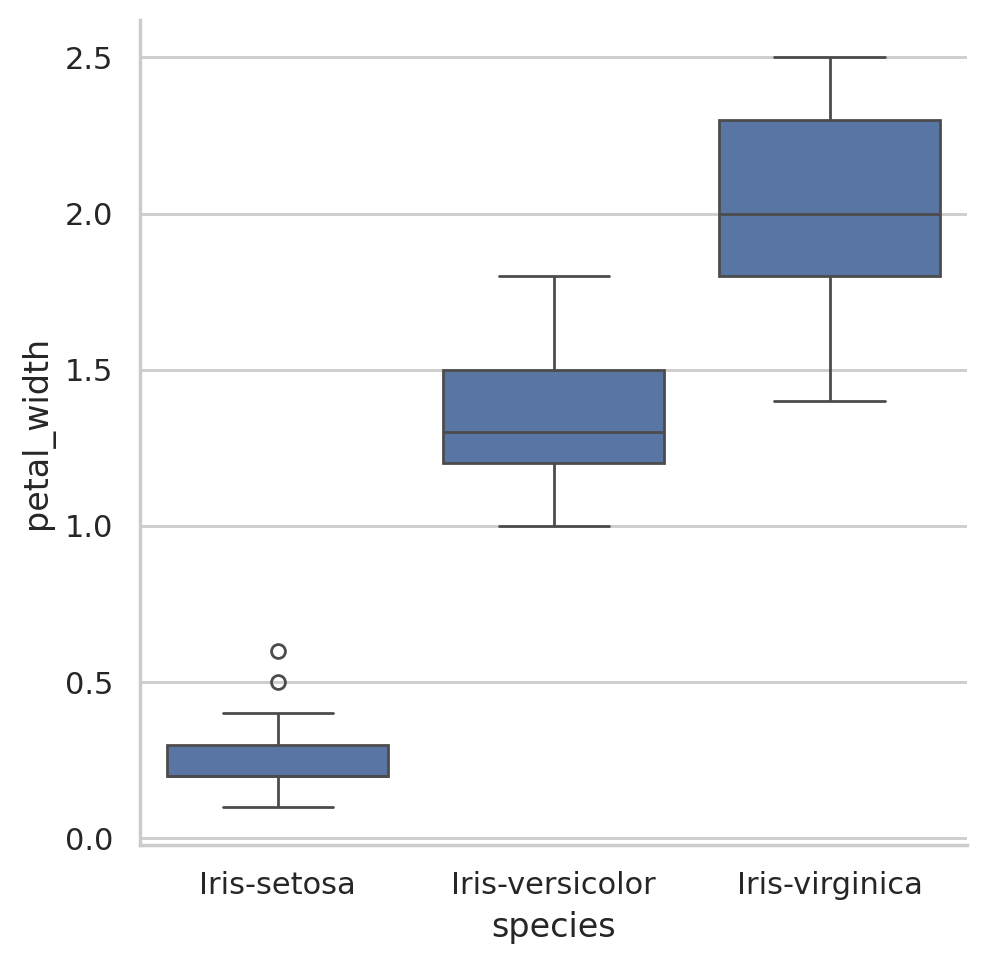

In [ ]:
sns.catplot(x = "species", y = "petal_width", kind = "box", data = iris);

A la vista del gráfico, observamos que las tres especies parecen diferentes entre sí respecto del ancho del pétalo (las cajas no solapan).  

Procedemos con los tests de normalidad e igualdad de varianzas para decidir que test de comparación debemos utilizar para resilver el contraste de interés.

In [ ]:
# Contraste de normalidad
print("Muestra1", stats.kstest(df1.petal_width, stats.norm.cdf,
                               args = (df1.petal_width.mean(), df1.petal_width.std())).pvalue)
print("Muestra2", stats.kstest(df2.petal_width, stats.norm.cdf,
                               args = (df2.petal_width.mean(), df2.petal_width.std())).pvalue)
print("Muestra3", stats.kstest(df3.petal_width, stats.norm.cdf,
                               args = (df3.petal_width.mean(), df3.petal_width.std())).pvalue)

Muestra1 1.2263157743616213e-05
Muestra2 0.20411175624782862
Muestra3 0.4257938210753581


Para los datos de la especie `Iris-setosa` no se verifica la hipótesis de normalidad, aunque como ya hemos dicho antes el test de igualdad de medias es abstante robusto nte la falta de normalidad. Veamos que ocurre con la igualdad de varianzas.

In [ ]:
stats.levene(df1.petal_width, df2.petal_width, df3.petal_width)

LeveneResult(statistic=19.412206652034453, pvalue=3.301949958497502e-08)

El p-valor resulta significativo indicando la falta de igualdad de varianzas. En esta situación tan solo podemos usar el test no paramétrico apra la comparación de los grupos. Veamos el resultado del proceso de inferencia:

In [ ]:
stats.kruskal(df1.petal_width, df2.petal_width, df3.petal_width)

KruskalResult(statistic=131.09335318823713, pvalue=3.415387999117524e-29)

El test resulta significativo lo que implica que al menos dos de las especies consideradas tienen media de la anchura de pétalo diferente.

**Longitud de pétalo**

En primer lugar representamos gráficamente la variable de interés.

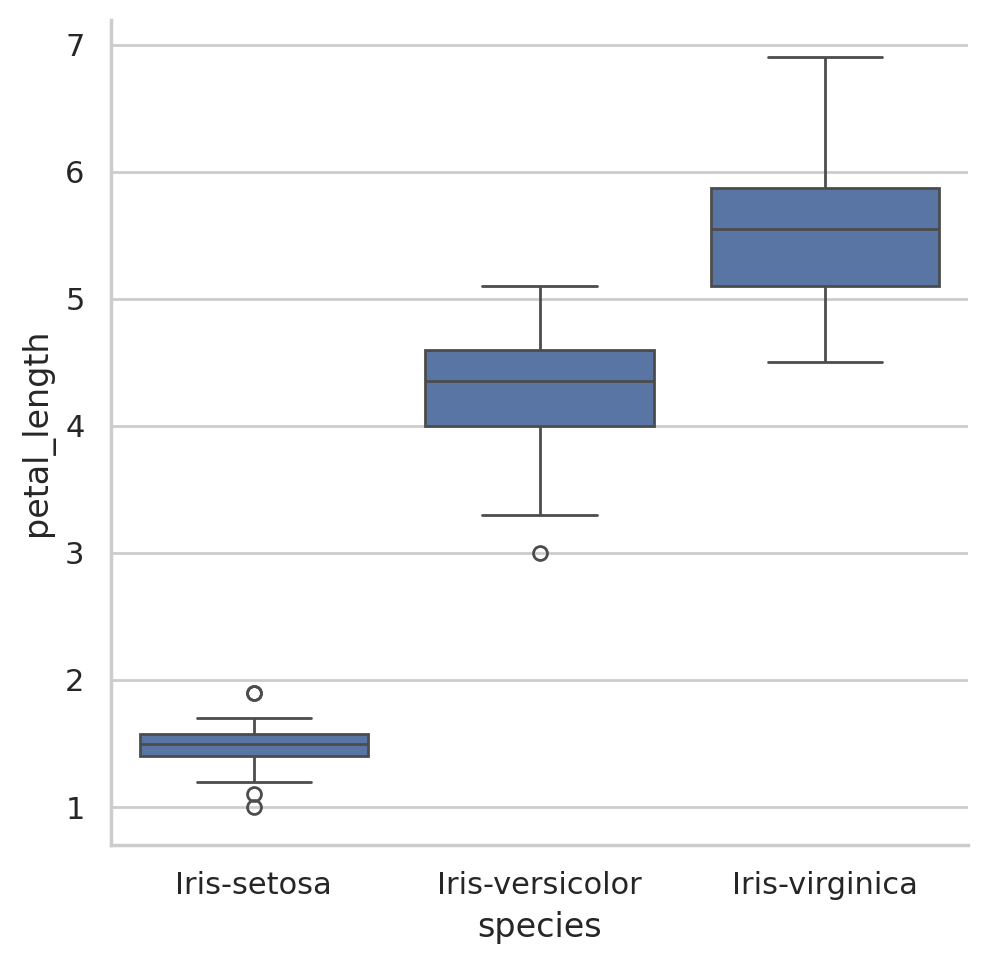

In [ ]:
sns.catplot(x = "species", y = "petal_length", kind = "box", data = iris);

¿Qué podemos concluir a la vista del gráfico?

Procedemos con los tests de normalidad e igualdad de varianzas.

In [ ]:
# Contraste de normalidad
print("Muestra1", stats.kstest(df1.petal_length, stats.norm.cdf,
                               args = (df1.petal_length.mean(), df1.petal_length.std())).pvalue)
print("Muestra2", stats.kstest(df2.petal_length, stats.norm.cdf,
                               args = (df2.petal_length.mean(), df2.petal_length.std())).pvalue)
print("Muestra3", stats.kstest(df3.petal_length, stats.norm.cdf,
                               args = (df3.petal_length.mean(), df3.petal_length.std())).pvalue)
# Contraste de igualdad de varianzas
stats.levene(df1.petal_length, df2.petal_length, df3.petal_length)

Muestra1 0.1486168768935111
Muestra2 0.4642415222366043
Muestra3 0.5028719892334554


LeveneResult(statistic=19.72005532503458, pvalue=2.5892961840828553e-08)

Se verifica la hipótesis de normalidad pero no ocurre lo mismo con la hipótesis de igualdad de varianzas. Procedemos con el test no paramétrico.

In [ ]:
stats.kruskal(df1.petal_length, df2.petal_length, df3.petal_length)

KruskalResult(statistic=130.41406912893967, pvalue=4.7967237479455454e-29)

El test resulta significativo lo que implica que al menos dos de las especies consideradas tienen media de la longitud de pétalo diferente.

**Anchura de sépalo**

En primer lugar representamos gráficamente la variable de interés.

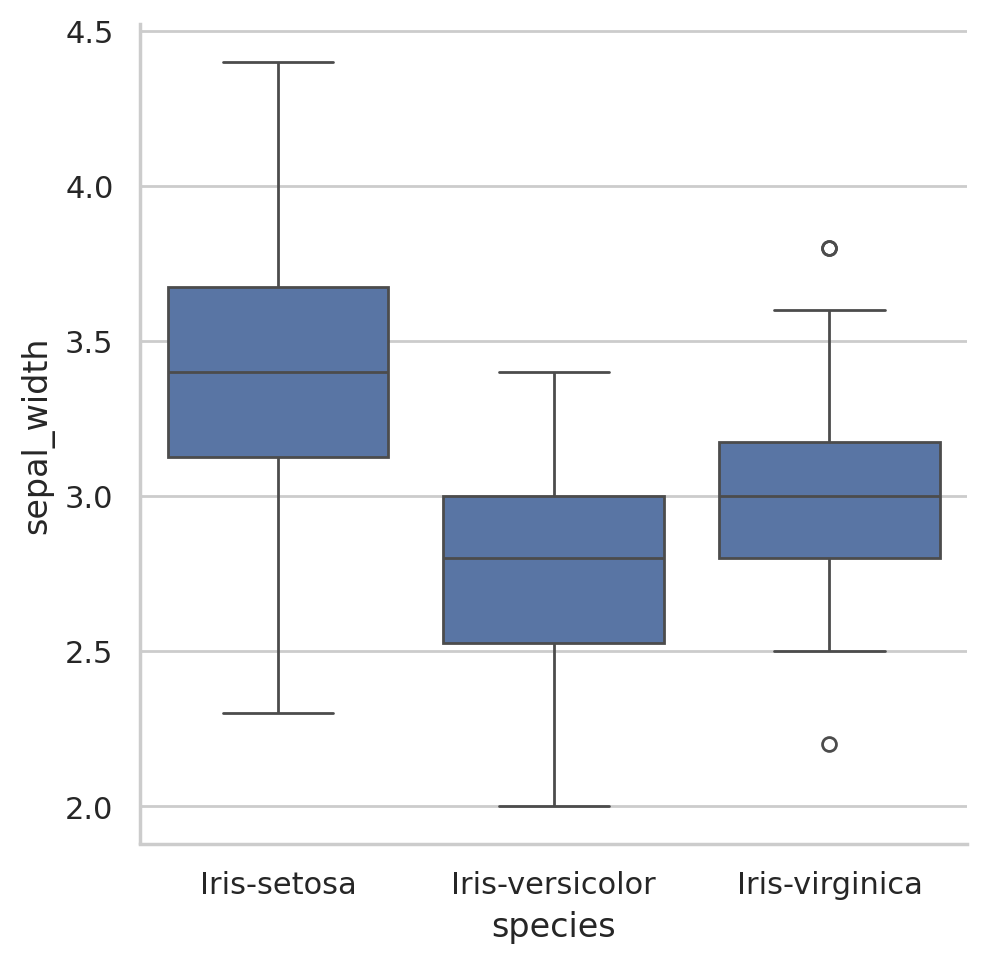

In [ ]:
sns.catplot(x = "species", y = "sepal_width", kind = "box", data = iris);

En este caso las poblaciones parecen más similares respecto de la anchura de sépalo. Veamos los tests de normalidad e igualdad de varianzas.

In [ ]:
# Contraste de normalidad
print("Muestra1", stats.kstest(df1.sepal_width, stats.norm.cdf,
                               args = (df1.sepal_width.mean(), df1.sepal_width.std())).pvalue)
print("Muestra2", stats.kstest(df2.petal_length, stats.norm.cdf,
                               args = (df2.sepal_width.mean(), df2.sepal_width.std())).pvalue)
print("Muestra3", stats.kstest(df3.petal_length, stats.norm.cdf,
                               args = (df3.sepal_width.mean(), df3.sepal_width.std())).pvalue)
# Contraste de igualdad de varianzas
stats.levene(df1.sepal_width, df2.sepal_width, df3.sepal_width)

Muestra1 0.4895630706222093
Muestra2 1.4124911280793952e-59
Muestra3 4.132844519573775e-298


LeveneResult(statistic=0.6475222363405327, pvalue=0.5248269975064537)

En este caso se verifica la hipótesis de igualdad de varianzas pero no la hipótesis de normalidad. NE este caso podemos optra tanto por el test parámetrico como el no parámetrico. Comenzamos con el test anova paramétrico:

In [ ]:
stats.f_oneway(df1.sepal_width, df2.sepal_width, df3.sepal_width)

F_onewayResult(statistic=47.36446140299382, pvalue=1.3279165184572242e-16)

El test resulta significativo indicando que al menos dos de los grupos tiene medias de de la anchura de sépalo diferentes. Procedemos con el test de comparación múltiples para estudiar las diferencas dos a dos.

In [ ]:
# Importamos la función
from statsmodels.stats.multicomp import pairwise_tukeyhsd
# Realizamos las comparaciones múltiples
res = pairwise_tukeyhsd(iris['sepal_width'], iris['species'])
print(res)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
     group1          group2     meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------
    Iris-setosa Iris-versicolor   -0.648   0.0 -0.8092 -0.4868   True
    Iris-setosa  Iris-virginica   -0.444   0.0 -0.6052 -0.2828   True
Iris-versicolor  Iris-virginica    0.204 0.009  0.0428  0.3652   True
---------------------------------------------------------------------


Dado que los tres tests de comparación dos a dos resultan significativos podemos concluir que existen diferencias en la media de la anchura de sépalo para cada par de especies.

**Longitud de sépalo**

En primer lugar representamos gráficamente la variable de interés.

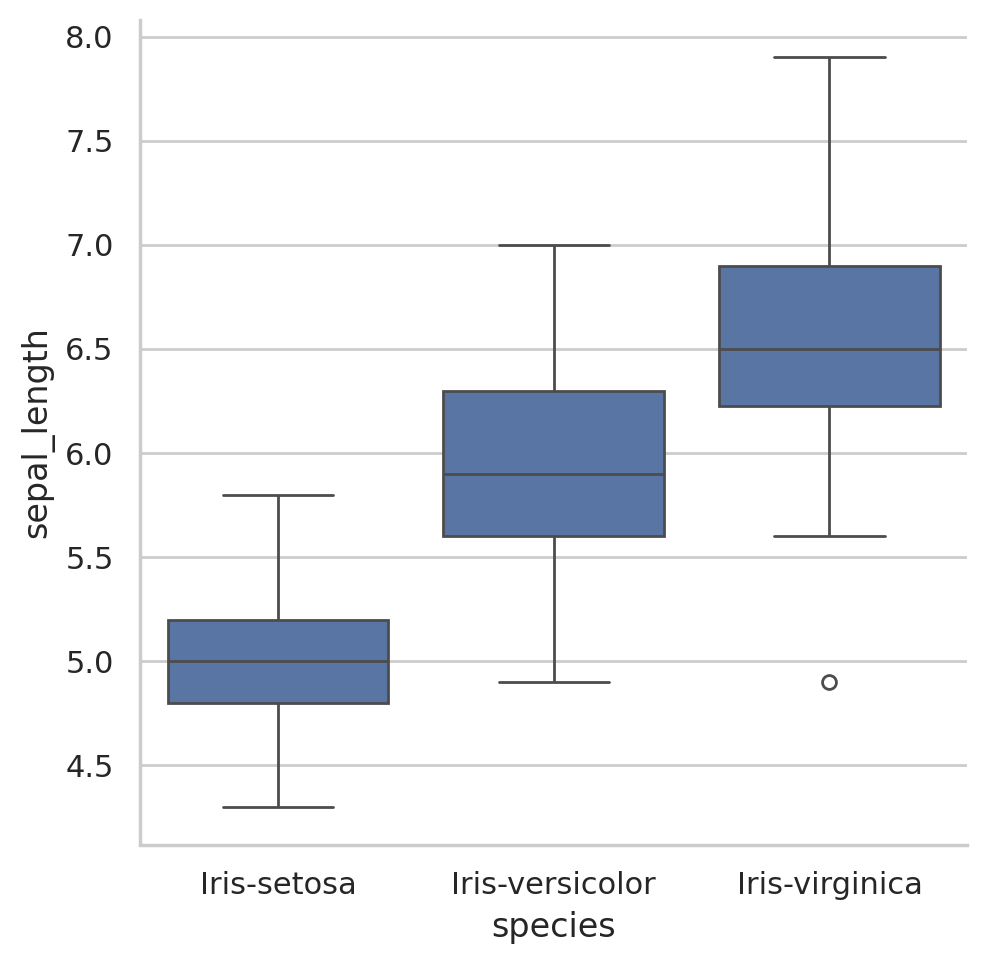

In [ ]:
sns.catplot(x = "species", y = "sepal_length", kind = "box", data = iris);

¿Qué podemos concluir del gráfico obtenido?

Veamos los tests de normalidad e igualdad de varianzas.

In [ ]:
# Contraste de normalidad
print("Muestra1", stats.kstest(df1.sepal_length, stats.norm.cdf,
                               args = (df1.sepal_length.mean(), df1.sepal_length.std())).pvalue)
print("Muestra2", stats.kstest(df2.sepal_length, stats.norm.cdf,
                               args = (df2.sepal_length.mean(), df2.sepal_length.std())).pvalue)
print("Muestra3", stats.kstest(df3.petal_length, stats.norm.cdf,
                               args = (df3.sepal_length.mean(), df3.sepal_length.std())).pvalue)
# Contraste de igualdad de varianzas
stats.levene(df1.sepal_length, df2.sepal_length, df3.sepal_length)

Muestra1 0.4889236515009082
Muestra2 0.7071234035717402
Muestra3 8.392724875547742e-22


LeveneResult(statistic=6.35272002048269, pvalue=0.0022585277836218586)

En este caso no se verifican las hipótesis de normalidad ni de igualdad de varianzas. Procedemos con el test no paramétrico.

In [ ]:
stats.kruskal(df1.sepal_length, df2.sepal_length, df3.sepal_length)

KruskalResult(statistic=96.93743600064833, pvalue=8.91873433246198e-22)

Dado que el p-valor resulta significativo podemos concluir que al menos dos especies tienen medias distintas de la losngitud de sépalo.